# Stack Ensemble Reabastecido

Esse notebook é uma evolução do `stack_ensemble.ipynb`. A ideia aqui é **reabastecer** o meta-modelo com mais informação.

No stack ensemble original, a Regressão Logística recebia **apenas** as 5 probabilidades dos modelos base como features. Ou seja, ela só sabia *o que cada modelo achou do jogo*, mas não sabia **nada** sobre o jogo em si.

Agora a gente muda isso para que alem das 5 probabilidades, o meta modelo vai receber também as **58 features originais** que os 5 modelos base usaram para fazer as previsões (isso é a estatísticas do time da casa e do visitante, como pontos, rebotes, assistências, e demais ... )

### Resumo da ideia:

- **Antes (stack ensemble original)**: 5 features → 5 probabilidades dos modelos base
- **Agora (reabastecido)**: 63 features → 5 probabilidades + 58 features originais

### Janela Incremental (mesma lógica de smp):

Para cada `Janela Incremental` e cada `Temporada`, o meta-modelo aprende **progressivamente** dentro da própria temporada:

- **Janela = 5**: treina com as linhas 1 a 5, prevê a 6. Depois treina com 1 a 6, prevê a 7°. E assim por diante.
- **Janela = 10**: treina com as linhas 1 a 10, prevê a 11°.
- **Janela = 15**: treina com as linhas 1 a 15, prevê a 16°.


Imagem para facilitar
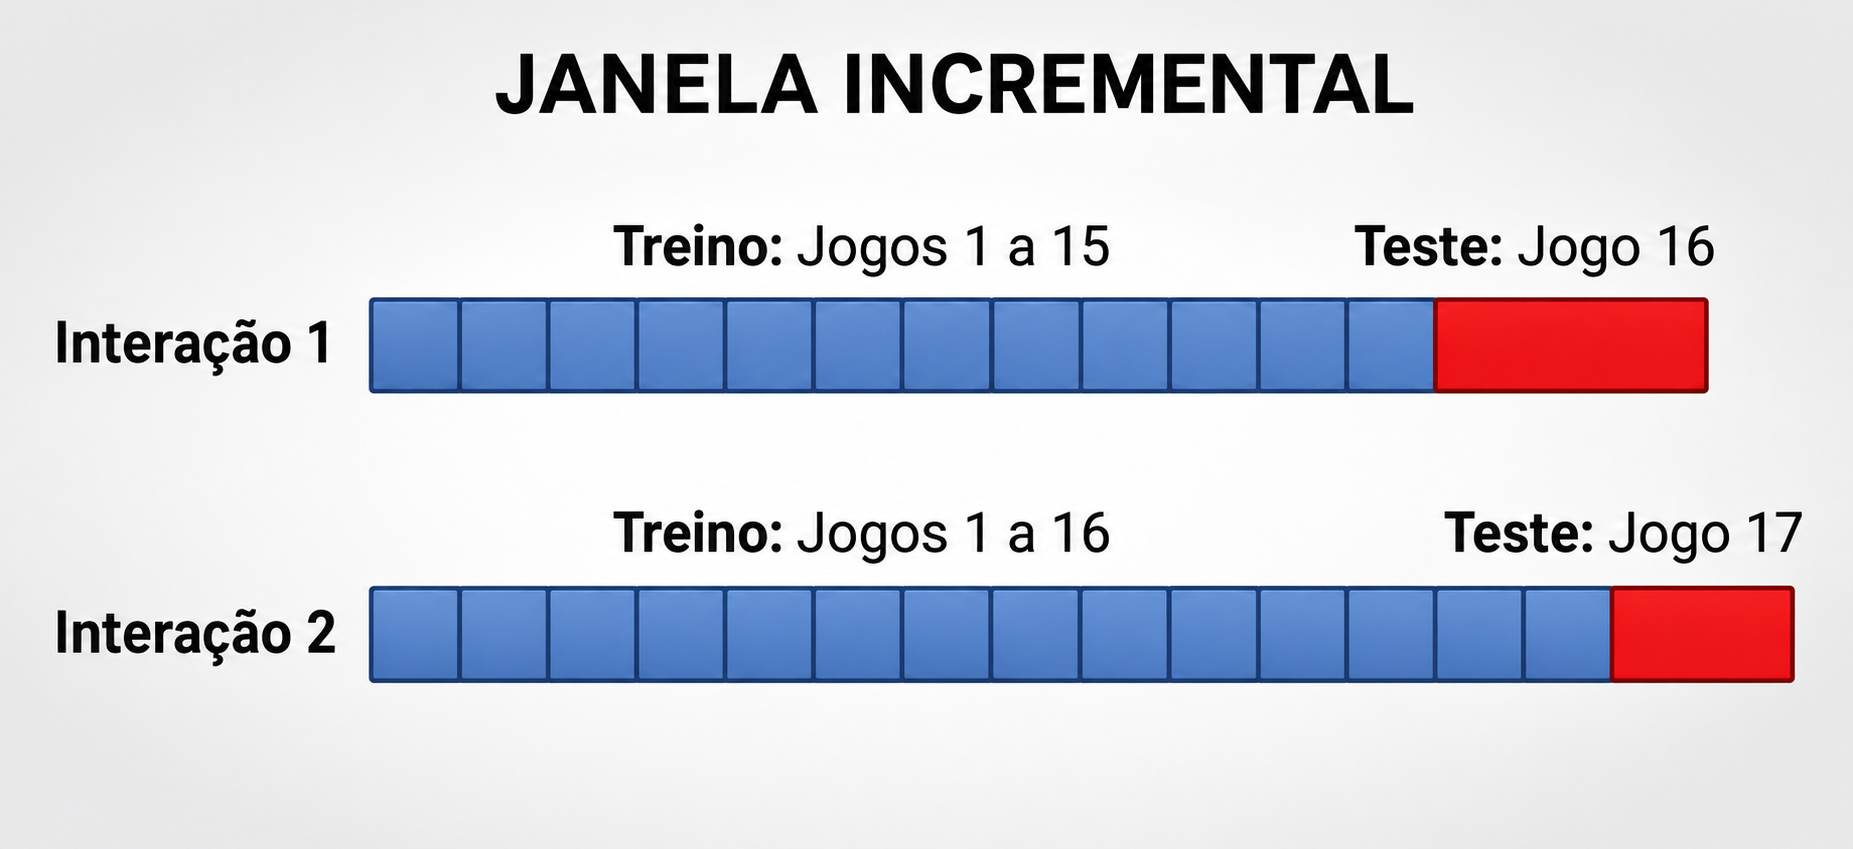

### Ponto de atenção:

Como agora temos **63 features** e as janelas menores começam com poucos jogos de treino 5, 10 e 15, tive que tomar cuidado com **overfitting**. então para evitar isso: 
- **Normalização (MinMaxScaler)**: as features originais têm escalas muito diferentes, então normalizamos tudo para a mesma escala
- **Regularização mais forte (C=0.1)**: para a Regressão Logística não se empolgar dms com tantas features kkk

### Features do meta-modelo:
As 5 probabilidades dos modelos base (`prob_svm`, `prob_knn`, `prob_extra_trees`, `prob_regressao_logistica`, `prob_lightgbm`) + as 58 features originais (estatísticas casa/visitante)

### Target:
`Resultado Real` (0 ou 1)

## Importar bibliotecas

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

## Configuração

Aqui defino todos os caminhos e configurações que vou usar ao longo do notebook:

- `META_DATASET_PATH`: o meta-dataset original (com as 5 probabilidades e o resultado real)
- `DETALHADO_PATH`: pasta com os CSVs detalhados do experimento 03 — preciso deles para descobrir de qual arquivo de teste cada jogo veio
- `DATA_PATH`: pasta dos dados originais do experimento 03, onde estão as 58 features
- `SAIDA_STACK`: pasta onde salvo os resultados do stack ensemble
- `SAIDA_EXP03`: resultados do experimento 03 (para os gráficos comparativos)

Para a Regressão Logística, usei parâmetros conservadores já que temos muitas features para poucas amostras nas janelas menores:
- `C=0.1`: regularização mais forte que o padrão (C=1.0)
- `max_iter=1000`: garante que o modelo converge
- `MinMaxScaler`: normaliza tudo para o intervalo [0, 1]

In [2]:
META_DATASET_PATH = os.path.abspath(
    os.path.join('..', 'results', 'experimento_04_stack', 'meta_dataset_stack.csv')
)
DETALHADO_PATH = os.path.abspath(
    os.path.join('..', 'results', 'experimento_03_detalhado')
)
DATA_PATH = os.path.abspath(
    os.path.join('..', 'data', 'experimento_03')
)
SAIDA_STACK = os.path.abspath(
    os.path.join('..', 'results', 'experimento_04_stack')
)
SAIDA_EXP03 = os.path.abspath(
    os.path.join('..', 'results', 'experimento_03')
)

PROB_FEATURES = [
    'prob_svm',
    'prob_knn',
    'prob_extra_trees',
    'prob_regressao_logistica',
    'prob_lightgbm',
]

COLUNAS_VAZAMENTO = [
    'placar_casa', 'placar_visitante', 'resultado',
    'data', 'ano', 'equipe_casa', 'equipe_visitante'
]

TARGET = 'Resultado Real'

JANELAS = [5, 10, 15]

print(f'Meta-dataset: {META_DATASET_PATH}')
print(f'Detalhado: {DETALHADO_PATH}')
print(f'Dados originais: {DATA_PATH}')
print(f'Saida: {SAIDA_STACK}')

Meta-dataset: c:\Users\Pedro conrado\Documents\stack-ensemble-prediction\results\experimento_04_stack\meta_dataset_stack.csv
Detalhado: c:\Users\Pedro conrado\Documents\stack-ensemble-prediction\results\experimento_03_detalhado
Dados originais: c:\Users\Pedro conrado\Documents\stack-ensemble-prediction\data\experimento_03
Saida: c:\Users\Pedro conrado\Documents\stack-ensemble-prediction\results\experimento_04_stack


## Carregar o meta-dataset original

Primeiro carrego o meta-dataset que foi gerado pelo notebook `meta-dataset.ipynb`. Ele tem 10.740 linhas (jogos), cada uma com as 5 probabilidades previstas pelos modelos base e o resultado real. É o nosso ponto de partida — depois vou enriquecer ele com as features originais.

In [3]:
df_meta = pd.read_csv(META_DATASET_PATH)

print(f'Shape: {df_meta.shape}')
print(f'Janelas: {sorted(df_meta["Janela Incremental"].unique())}')
print(f'Temporadas: {sorted(df_meta["Temporada"].unique())}')
print(f'Colunas: {df_meta.columns.tolist()}')
df_meta.head()

Shape: (10740, 9)
Janelas: [np.int64(5), np.int64(10), np.int64(15)]
Temporadas: ['2008-2009', '2009-2010', '2011-2012', '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023', '2023-2024']
Colunas: ['Janela Incremental', 'Temporada', 'Ordem Jogo Temporada', 'Resultado Real', 'prob_svm', 'prob_knn', 'prob_extra_trees', 'prob_regressao_logistica', 'prob_lightgbm']


,Janela Incremental,Temporada,Ordem Jogo Temporada,Resultado Real,prob_svm,prob_knn,prob_extra_trees,prob_regressao_logistica,prob_lightgbm
0,5,2008-2009,1,1,0.733335,0.666667,0.800000,0.799964,0.800000
1,5,2008-2009,2,0,0.769852,0.666667,0.833333,0.833331,0.833333
2,5,2008-2009,3,0,0.238587,0.333333,0.097143,0.535707,0.600000
3,5,2008-2009,4,1,0.190341,0.000000,0.097143,0.405470,0.545455
4,5,2008-2009,5,1,0.561735,0.333333,0.574286,0.551301,0.583333


## Construção do meta-dataset reabastecido


A ideia é a seguinte: para cada jogo no meta-dataset, eu preciso **voltar no CSV de teste original** e pegar as 58 features estatísticas que os modelos base usaram para fazer a previsão daquele jogo.

**eai qual foi a ideia:**

1. fazer o caminhos inverso para pegar exatamente as features originais, então eu carrego o CSV detalhado do SVM (qualquer um dos 5 serviria, escolhi o SVM por ser o primeiro) ele tem as colunas `Subpasta`, `Teste Arquivo` e `Posicao no Teste` que me dizem **exatamente** de qual arquivo de teste cada jogo veio
2. Com essa informação, consigo construir o caminho: `data/experimento_03/{janela}/{temporada}/{subpasta}/{teste_arquivo}` e pegar as features originais na posição correta
3. Junto tudo num DataFrame só: as 5 probabilidades + as 58 features originais

No final, o meta-dataset reabastecido vai ter **63 features** para o meta-modelo usar, em vez das 5 que tínhamos antes!

**Obs:** esse processo carrega vários milhares de CSVs pequenos, então pode demorar um minutinho. Fiz um progresso na tela para acompanhar.

In [4]:
# Carregar CSV detalhado do SVM para obter o mapeamento de cada jogo
df_svm_det = pd.read_csv(
    os.path.join(DETALHADO_PATH, 'svm_experimento_03_predicoes_detalhadas.csv')
)

# Colunas que preciso para mapear cada jogo ao CSV de teste original
df_mapping = df_svm_det[[
    'Janela Incremental', 'Temporada', 'Ordem Jogo Temporada',
    'Subpasta', 'Teste Arquivo', 'Posicao no Teste'
]].copy()

print(f'Mapeamento carregado: {len(df_mapping)} linhas')
print(f'Exemplo:')
df_mapping.head(3)

Mapeamento carregado: 10740 linhas
Exemplo:


,Janela Incremental,Temporada,Ordem Jogo Temporada,Subpasta,Teste Arquivo,Posicao no Teste
0,5,2008-2009,1,5-1,teste_1.csv,1
1,5,2008-2009,2,6-1,teste_2.csv,1
2,5,2008-2009,3,10-1,teste_6.csv,1


In [5]:
# Agrupar por (Janela, Temporada, Subpasta, Teste Arquivo)
# para carregar cada CSV de teste uma unica vez
grouped = df_mapping.groupby(
    ['Janela Incremental', 'Temporada', 'Subpasta', 'Teste Arquivo']
)
total_groups = len(grouped)

print(f'Total de arquivos de teste para carregar: {total_groups}')
print(f'Carregando as features originais...\n')

all_rows = []
loaded = 0

for (janela, temporada, subpasta, teste_arquivo), group in grouped:
    loaded += 1
    if loaded % 2000 == 0:
        print(f'  Progresso: {loaded}/{total_groups} arquivos carregados...')

    teste_path = os.path.join(
        DATA_PATH, str(janela), temporada, subpasta, teste_arquivo
    )
    df_teste = pd.read_csv(teste_path)
    df_teste_features = df_teste.drop(columns=COLUNAS_VAZAMENTO, errors='ignore')

    for _, row in group.iterrows():
        posicao = int(row['Posicao no Teste']) - 1
        feat_dict = df_teste_features.iloc[posicao].to_dict()
        feat_dict['Janela Incremental'] = janela
        feat_dict['Temporada'] = temporada
        feat_dict['Ordem Jogo Temporada'] = int(row['Ordem Jogo Temporada'])
        all_rows.append(feat_dict)

df_features_originais = pd.DataFrame(all_rows)
print(f'\nFeatures originais carregadas: {df_features_originais.shape}')

# Determinar quais sao as features originais (excluindo as colunas de merge)
ORIGINAL_FEATURES = [
    col for col in df_features_originais.columns
    if col not in ['Janela Incremental', 'Temporada', 'Ordem Jogo Temporada']
]
print(f'Features originais encontradas: {len(ORIGINAL_FEATURES)}')
print(f'Lista: {ORIGINAL_FEATURES}')

# Fazer o merge com o meta dataset
df_enriched = df_meta.merge(
    df_features_originais,
    on=['Janela Incremental', 'Temporada', 'Ordem Jogo Temporada'],
    how='inner'
)

# Definir as features completas (5 probabilidades + 58 orig)
ALL_FEATURES = PROB_FEATURES + ORIGINAL_FEATURES

print(f'\nMeta-dataset reabastecido:')
print(f'  Shape: {df_enriched.shape}')
print(f'  Total de features para o meta-modelo: {len(ALL_FEATURES)}')
print(f'    - Probabilidades dos modelos: {len(PROB_FEATURES)}')
print(f'    - Features originais: {len(ORIGINAL_FEATURES)}')

Total de arquivos de teste para carregar: 10740
Carregando as features originais...

  Progresso: 2000/10740 arquivos carregados...
  Progresso: 4000/10740 arquivos carregados...
  Progresso: 6000/10740 arquivos carregados...
  Progresso: 8000/10740 arquivos carregados...
  Progresso: 10000/10740 arquivos carregados...

Features originais carregadas: (10740, 61)
Features originais encontradas: 58
Lista: ['round', 'stage', 'Pts_casa', '3P_casa', '2P_casa', 'LL_casa', 'RT_casa', 'RO_casa', 'RD_casa', 'AS_casa', 'ER_casa', 'IA%_casa', '3PC_casa', '3PT_casa', '3P%_casa', '2PC_casa', '2PT_casa', '2P%_casa', 'LLC_casa', 'LLT_casa', 'LL%_casa', 'EN_casa', 'BR_casa', 'B/E_casa', 'TO_casa', 'FC_casa', 'T/FC_casa', 'ET_casa', 'VI_casa', 'EF_casa', 'Pts_visitante', '3P_visitante', '2P_visitante', 'LL_visitante', 'RT_visitante', 'RO_visitante', 'RD_visitante', 'AS_visitante', 'ER_visitante', 'IA%_visitante', '3PC_visitante', '3PT_visitante', '3P%_visitante', '2PC_visitante', '2PT_visitante', '2P%_

## Validação do meta-dataset reabastecido

Antes de rodar o stack ensemble, preciso garantir que o merge deu certo. Vou conferir se não perdi nenhuma linha e se não tem valores nulos nas features. Se algo deu errado aqui, os resultados do stack vão ser furados.

In [6]:
print(f'Linhas no meta-dataset original: {len(df_meta)}')
print(f'Linhas no meta-dataset reabastecido: {len(df_enriched)}')
print(f'Linhas perdidas no merge: {len(df_meta) - len(df_enriched)}')
print()

nulos = df_enriched[ALL_FEATURES].isna().sum().sum()
print(f'Valores nulos nas features: {nulos}')

if len(df_enriched) == len(df_meta) and nulos == 0:
    print('\nTudo certo! O meta-dataset reabastecido esta integro.')
else:
    print('\nAtencao! Verifique os dados.')

print(f'\nPrimeiras linhas do dataset reabastecido:')
df_enriched.head(3)

Linhas no meta-dataset original: 10740
Linhas no meta-dataset reabastecido: 10740
Linhas perdidas no merge: 0

Valores nulos nas features: 0

Tudo certo! O meta-dataset reabastecido esta integro.

Primeiras linhas do dataset reabastecido:


,Janela Incremental,Temporada,Ordem Jogo Temporada,Resultado Real,prob_svm,prob_knn,prob_extra_trees,prob_regressao_logistica,prob_lightgbm,round,...,LL%_visitante,EN_visitante,BR_visitante,B/E_visitante,TO_visitante,FC_visitante,T/FC_visitante,ET_visitante,VI_visitante,EF_visitante
0,5,2008-2009,1,1,0.733335,0.666667,0.800000,0.799964,0.800000,1.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0
1,5,2008-2009,2,0,0.769852,0.666667,0.833333,0.833331,0.833333,1.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0
2,5,2008-2009,3,0,0.238587,0.333333,0.097143,0.535707,0.600000,2.0,...,69.57,1.0,9.0,0.6,2.0,26.0,0.08,15.0,0.0,85.0


## Implementação do Stack Ensemble Reabastecido

Aqui a lógica é a mesma do stack ensemble original, mas com duas diferenças importantes:

1. **Mais features**: agora o meta-modelo recebe **63 features** em vez de 5
2. **Normalização**: como as features têm escalas muito diferentes (pontos podem chegar a 100+, enquanto probabilidades ficam entre 0 e 1), eu uso o `MinMaxScaler` para colocar tudo na mesma escala antes de treinar. O scaler faz `fit` no treino e `transform` no teste a cada iteração, como deve ser.

A Regressão Logística com `C=0.1` dá uma regularização mais forte, o que ajuda a evitar overfitting, principalmente nas janelas menores (janela=5) onde temos muito mais features do que amostras de treino.

**Obs:** Assim como nos outros notebooks, quando o `y_train` tem apenas uma classe (só vitória ou só derrota), previ diretamente essa classe sem treinar o modelo.

In [7]:
todas_predicoes = []
resultados_resumo = []

for janela in JANELAS:
    df_janela = df_enriched[df_enriched['Janela Incremental'] == janela].copy()
    temporadas = sorted(df_janela['Temporada'].unique())

    for temporada in temporadas:
        df_temp = df_janela[df_janela['Temporada'] == temporada].copy()
        df_temp = df_temp.sort_values('Ordem Jogo Temporada').reset_index(drop=True)

        n_jogos = len(df_temp)

        if n_jogos <= janela:
            print(
                f'[AVISO] Janela={janela} | {temporada} | '
                f'Apenas {n_jogos} jogos, insuficiente para treinar e prever. Pulando.'
            )
            continue

        y_true_temp = []
        y_pred_temp = []
        y_prob_temp = []

        for i in range(janela, n_jogos):
            X_train = df_temp.loc[:i-1, ALL_FEATURES]
            y_train = df_temp.loc[:i-1, TARGET]

            X_test = df_temp.loc[[i], ALL_FEATURES]
            y_test = df_temp.loc[i, TARGET]

            if y_train.nunique() < 2:
                classe_unica = int(y_train.iloc[0])
                pred = classe_unica
                prob_classe_1 = 1.0 if classe_unica == 1 else 0.0
            else:
                scaler = MinMaxScaler()
                X_train_scaled = scaler.fit_transform(X_train)
                X_test_scaled = scaler.transform(X_test)

                meta_model = LogisticRegression(
                    C=0.1,
                    solver='lbfgs',
                    max_iter=1000,
                    random_state=42
                )
                meta_model.fit(X_train_scaled, y_train)

                pred = meta_model.predict(X_test_scaled)[0]
                prob = meta_model.predict_proba(X_test_scaled)[0]
                prob_classe_1 = float(prob[1]) if len(prob) > 1 else float(prob[0])

            y_true_temp.append(int(y_test))
            y_pred_temp.append(int(pred))
            y_prob_temp.append(prob_classe_1)

            todas_predicoes.append({
                'Janela Incremental': janela,
                'Temporada': temporada,
                'Ordem Jogo Temporada': int(df_temp.loc[i, 'Ordem Jogo Temporada']),
                'Resultado Real': int(y_test),
                'Previsao': int(pred),
                'Probabilidade Classe 1': prob_classe_1,
            })

        if len(y_true_temp) > 0:
            acc = accuracy_score(y_true_temp, y_pred_temp)
            f1 = f1_score(y_true_temp, y_pred_temp, average='weighted', zero_division=0)

            resultados_resumo.append({
                'Janela Incremental': janela,
                'Temporada': temporada,
                'Jogos Avaliados': len(y_true_temp),
                'Acur\u00e1cia': round(acc, 4),
                'F1-Score': round(f1, 4),
            })

            print(
                f'Janela={janela} | {temporada} | '
                f'Jogos: {len(y_true_temp)} | '
                f'Acuracia: {acc:.4f} | '
                f'F1: {f1:.4f}'
            )

print(f'\nTotal de predicoes: {len(todas_predicoes)}')

Janela=5 | 2008-2009 | Jogos: 226 | Acuracia: 0.6726 | F1: 0.6370
Janela=5 | 2009-2010 | Jogos: 151 | Acuracia: 0.6623 | F1: 0.5330
Janela=5 | 2011-2012 | Jogos: 165 | Acuracia: 0.6545 | F1: 0.5519
Janela=5 | 2012-2013 | Jogos: 339 | Acuracia: 0.6549 | F1: 0.6002
Janela=5 | 2013-2014 | Jogos: 305 | Acuracia: 0.6230 | F1: 0.5798
Janela=5 | 2014-2015 | Jogos: 274 | Acuracia: 0.6095 | F1: 0.5001
Janela=5 | 2015-2016 | Jogos: 244 | Acuracia: 0.5738 | F1: 0.5591
Janela=5 | 2016-2017 | Jogos: 249 | Acuracia: 0.5261 | F1: 0.4650
Janela=5 | 2018-2019 | Jogos: 207 | Acuracia: 0.6087 | F1: 0.5535
Janela=5 | 2019-2020 | Jogos: 196 | Acuracia: 0.5561 | F1: 0.5542
Janela=5 | 2020-2021 | Jogos: 255 | Acuracia: 0.6588 | F1: 0.6269
Janela=5 | 2021-2022 | Jogos: 293 | Acuracia: 0.6451 | F1: 0.5969
Janela=5 | 2022-2023 | Jogos: 301 | Acuracia: 0.5847 | F1: 0.5656
Janela=5 | 2023-2024 | Jogos: 375 | Acuracia: 0.6400 | F1: 0.6103
Janela=10 | 2008-2009 | Jogos: 216 | Acuracia: 0.7176 | F1: 0.6835
Janela=10

## Salvar resultados

Salvei dois CSVs, no mesmo esquema dos outros notebooks:
- **Predições detalhadas**: cada linha é uma previsão do stack reabastecido com a probabilidade
- **Resumo por temporada**: acurácia e F1-Score agregados por janela e temporada

In [8]:
os.makedirs(SAIDA_STACK, exist_ok=True)

df_predicoes = pd.DataFrame(todas_predicoes)
predicoes_path = os.path.join(SAIDA_STACK, 'stack_ensemble_reabastecido_predicoes.csv')
df_predicoes.to_csv(predicoes_path, index=False)
print(f'Predicoes salvas em: {predicoes_path}')
print(f'Shape: {df_predicoes.shape}')

df_resumo_reab = pd.DataFrame(resultados_resumo)
resumo_path = os.path.join(SAIDA_STACK, 'stack_ensemble_reabastecido_resumo.csv')
df_resumo_reab.to_csv(resumo_path, index=False)
print(f'\nResumo salvo em: {resumo_path}')
print(df_resumo_reab.to_string(index=False))

Predicoes salvas em: c:\Users\Pedro conrado\Documents\stack-ensemble-prediction\results\experimento_04_stack\stack_ensemble_reabastecido_predicoes.csv
Shape: (10320, 6)

Resumo salvo em: c:\Users\Pedro conrado\Documents\stack-ensemble-prediction\results\experimento_04_stack\stack_ensemble_reabastecido_resumo.csv
 Janela Incremental Temporada  Jogos Avaliados  Acurácia  F1-Score
                  5 2008-2009              226    0.6726    0.6370
                  5 2009-2010              151    0.6623    0.5330
                  5 2011-2012              165    0.6545    0.5519
                  5 2012-2013              339    0.6549    0.6002
                  5 2013-2014              305    0.6230    0.5798
                  5 2014-2015              274    0.6095    0.5001
                  5 2015-2016              244    0.5738    0.5591
                  5 2016-2017              249    0.5261    0.4650
                  5 2018-2019              207    0.6087    0.5535
                

## Função de Plot

Criei a função `plot_comparativo(janela)` que gera um gráfico comparando o stack reabastecido com todo mundo:
- Os 5 modelos individuais (SVM, KNN, Extra Trees, Regressão Logística, LightGBM)
- O voto majoritário
- O soft voting
- O stack ensemble com Regressão Logística (5 features)
- O stack ensemble com XGBoost (5 features)
- O **stack reabastecido** (63 features) — em destaque!

Assim consigo visualizar de uma vez se o reabastecimento trouxe alguma melhora real.

In [9]:
def plot_comparativo(janela):
    modelos = {
        'SVM':                'svm',
        'KNN':                'knn',
        'Extra Trees':        'extra_trees',
        'Regressao Logistica':'regressao_logistica',
        'LightGBM':           'lightgbm',
    }

    jogos_por_temporada = {
        '2008-2009': 237, '2009-2010': 162, '2011-2012': 176,
        '2012-2013': 350, '2013-2014': 316, '2014-2015': 285,
        '2015-2016': 255, '2016-2017': 260, '2018-2019': 218,
        '2019-2020': 207, '2020-2021': 266, '2021-2022': 304,
        '2022-2023': 312, '2023-2024': 386
    }

    cores = {
        'SVM':                '#1f77b4',
        'KNN':                '#ff7f0e',
        'Extra Trees':        '#2ca02c',
        'Regressao Logistica':'#d62728',
        'LightGBM':           '#9467bd',
    }

    marcadores = {
        'SVM':                'o',
        'KNN':                's',
        'Extra Trees':        '^',
        'Regressao Logistica':'D',
        'LightGBM':           'P',
    }

    cores_ensemble = {
        'Voto Majoritario':            'gray',
        'Soma de Votos':               'dimgray',
        'Stack (Log. Reg.)':           'blue',
        'Stack (XGBoost)':             'orange',
        'Stack Reabastecido (63 feat.)': 'red',
    }

    temporadas_order = list(jogos_por_temporada.keys())

    # Carregar modelos individuais
    dfs_plot = []
    for nome_modelo, arquivo_modelo in modelos.items():
        path = os.path.join(
            SAIDA_EXP03,
            f'{arquivo_modelo}_experimento_03_janela{janela}.csv'
        )
        if not os.path.exists(path):
            continue
        df_m = pd.read_csv(path)
        df_m['Modelo'] = nome_modelo
        dfs_plot.append(df_m)

    dados_plot = pd.concat(dfs_plot, ignore_index=True)
    dados_plot['F1-Score'] = dados_plot['F1-Score'].astype(float)
    dados_plot['Temporada'] = pd.Categorical(
        dados_plot['Temporada'], categories=temporadas_order, ordered=True
    )
    dados_plot = dados_plot.sort_values('Temporada')

    ensembles = {}

    # Voto majoritario
    voto_path = os.path.join(SAIDA_EXP03, 'ensemble_voto_majoritario.csv')
    if os.path.exists(voto_path):
        df_voto = pd.read_csv(voto_path)
        df_voto = df_voto[df_voto['Janela Incremental'] == janela].copy()
        df_voto['F1-Score'] = df_voto['F1-Score'].astype(float)
        df_voto['Temporada'] = pd.Categorical(
            df_voto['Temporada'], categories=temporadas_order, ordered=True
        )
        df_voto = df_voto.sort_values('Temporada')
        ensembles['Voto Majoritario'] = df_voto

    # Soma de votos
    soft_path = os.path.join(SAIDA_EXP03, 'ensemble_soft_voting.csv')
    if os.path.exists(soft_path):
        df_soft = pd.read_csv(soft_path)
        df_soft = df_soft[df_soft['Janela Incremental'] == janela].copy()
        df_soft['F1-Score'] = df_soft['F1-Score'].astype(float)
        df_soft['Temporada'] = pd.Categorical(
            df_soft['Temporada'], categories=temporadas_order, ordered=True
        )
        df_soft = df_soft.sort_values('Temporada')
        ensembles['Soma de Votos'] = df_soft

    # Stack LR original (5 features)
    lr_path = os.path.join(SAIDA_STACK, 'stack_ensemble_resumo.csv')
    if os.path.exists(lr_path):
        df_lr = pd.read_csv(lr_path)
        df_lr = df_lr[df_lr['Janela Incremental'] == janela].copy()
        df_lr['F1-Score'] = df_lr['F1-Score'].astype(float)
        df_lr['Temporada'] = pd.Categorical(
            df_lr['Temporada'], categories=temporadas_order, ordered=True
        )
        df_lr = df_lr.sort_values('Temporada')
        ensembles['Stack (Log. Reg.)'] = df_lr

    # Stack XGBoost (5 features)
    xgb_path = os.path.join(SAIDA_STACK, 'stack_ensemble_xgboost_resumo.csv')
    if os.path.exists(xgb_path):
        df_xgb = pd.read_csv(xgb_path)
        df_xgb = df_xgb[df_xgb['Janela Incremental'] == janela].copy()
        df_xgb['F1-Score'] = df_xgb['F1-Score'].astype(float)
        df_xgb['Temporada'] = pd.Categorical(
            df_xgb['Temporada'], categories=temporadas_order, ordered=True
        )
        df_xgb = df_xgb.sort_values('Temporada')
        ensembles['Stack (XGBoost)'] = df_xgb

    # Stack Reabastecido (63 features) - o nosso!
    df_stack = df_resumo_reab[df_resumo_reab['Janela Incremental'] == janela].copy()
    df_stack['Temporada'] = pd.Categorical(
        df_stack['Temporada'], categories=temporadas_order, ordered=True
    )
    df_stack = df_stack.sort_values('Temporada')
    df_stack['F1-Score'] = df_stack['F1-Score'].astype(float)

    # --- Plot ---
    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(16, 9),
        gridspec_kw={'height_ratios': [3, 1]},
        sharex=True
    )

    # Modelos individuais
    for nome_modelo in modelos.keys():
        subset = dados_plot[dados_plot['Modelo'] == nome_modelo].sort_values('Temporada')
        ax1.plot(
            subset['Temporada'],
            subset['F1-Score'],
            marker=marcadores[nome_modelo],
            color=cores[nome_modelo],
            linewidth=1.5,
            markersize=5,
            label=nome_modelo,
            alpha=0.4
        )

    # Voto Majoritario
    if 'Voto Majoritario' in ensembles:
        df_e = ensembles['Voto Majoritario']
        ax1.plot(
            df_e['Temporada'], df_e['F1-Score'],
            marker='x', color=cores_ensemble['Voto Majoritario'], linewidth=1.5, markersize=7,
            linestyle=':', label='Voto Majoritario', alpha=0.5
        )

    # Soma de Votos
    if 'Soma de Votos' in ensembles:
        df_e = ensembles['Soma de Votos']
        ax1.plot(
            df_e['Temporada'], df_e['F1-Score'],
            marker='+', color=cores_ensemble['Soma de Votos'], linewidth=1.5, markersize=7,
            linestyle='-.', label='Soma de Votos', alpha=0.5
        )

    # Stack LR original
    if 'Stack (Log. Reg.)' in ensembles:
        df_e = ensembles['Stack (Log. Reg.)']
        ax1.plot(
            df_e['Temporada'], df_e['F1-Score'],
            marker='d', color=cores_ensemble['Stack (Log. Reg.)'], linewidth=2, markersize=8,
            linestyle='--', label='Stack (Log. Reg.)', alpha=0.7
        )

    # Stack XGBoost
    if 'Stack (XGBoost)' in ensembles:
        df_e = ensembles['Stack (XGBoost)']
        ax1.plot(
            df_e['Temporada'], df_e['F1-Score'],
            marker='v', color=cores_ensemble['Stack (XGBoost)'], linewidth=2, markersize=8,
            linestyle='--', label='Stack (XGBoost)', alpha=0.7
        )

    # Stack Reabastecido - DESTAQUE
    ax1.plot(
        df_stack['Temporada'],
        df_stack['F1-Score'],
        marker='*',
        color=cores_ensemble['Stack Reabastecido (63 feat.)'],
        linewidth=3,
        markersize=12,
        linestyle='--',
        label='Stack Reabastecido (63 feat.)',
        zorder=10
    )

    # --- Labels: melhor valor em cada temporada ---
    for temporada in temporadas_order:
        candidatos = {}
        for nome in modelos.keys():
            arr = dados_plot[
                (dados_plot['Modelo'] == nome) &
                (dados_plot['Temporada'] == temporada)
            ]['F1-Score'].values
            if len(arr) > 0:
                candidatos[nome] = (arr[0], cores[nome])
        for nome_ens, df_e in ensembles.items():
            arr = df_e[df_e['Temporada'] == temporada]['F1-Score'].values
            if len(arr) > 0:
                candidatos[nome_ens] = (arr[0], cores_ensemble.get(nome_ens, 'black'))
        arr_stack = df_stack[df_stack['Temporada'] == temporada]['F1-Score'].values
        if len(arr_stack) > 0:
            candidatos['Stack Reabastecido (63 feat.)'] = (arr_stack[0], cores_ensemble['Stack Reabastecido (63 feat.)'])

        if not candidatos:
            continue

        melhor_nome = max(candidatos, key=lambda k: candidatos[k][0])
        melhor_valor, cor_label = candidatos[melhor_nome]

        ax1.annotate(
            f'{melhor_valor:.2f}',
            xy=(temporada, melhor_valor),
            xytext=(0, 8),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold',
            color=cor_label,
            bbox=dict(
                boxstyle='round,pad=0.2',
                facecolor='white',
                edgecolor='none',
                alpha=0.75
            )
        )

    # --- Linha de referencia: media Stack Reabastecido ---
    media_stack = float(df_stack['F1-Score'].mean())
    ax1.axhline(
        media_stack,
        color='#444444',
        linestyle='--',
        linewidth=1.3,
        alpha=0.8,
        label=f'Media Stack ({media_stack:.2f})'
    )
    ax1.text(
        x=len(temporadas_order) - 0.5,
        y=media_stack + 0.006,
        s=f'Media: {media_stack:.2f}',
        color='#333333',
        fontsize=9,
        fontweight='bold',
        ha='right',
        va='bottom',
        bbox=dict(
            boxstyle='square,pad=0.2',
            facecolor='white',
            edgecolor='#cccccc',
            alpha=0.85
        )
    )

    ax1.set_ylabel('F1-Score (weighted)', fontsize=12)
    ax1.set_ylim(0.45, 0.90)
    ax1.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
    ax1.legend(loc='upper right', fontsize=8, ncol=2)
    ax1.grid(axis='y', linestyle='--', alpha=0.5)
    ax1.tick_params(axis='x', rotation=45)

    # Barra de jogos por temporada
    temporadas_presentes = [t for t in temporadas_order if t in jogos_por_temporada]
    jogos_vals = [jogos_por_temporada[t] for t in temporadas_presentes]

    ax2.bar(
        temporadas_presentes, jogos_vals,
        color='#1f77b4', alpha=0.4, edgecolor='#1f77b4'
    )
    for i, v in enumerate(jogos_vals):
        ax2.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=8)

    ax2.set_ylabel('Jogos', fontsize=10)
    ax2.set_ylim(0, max(jogos_vals) * 1.25)
    ax2.grid(axis='y', linestyle='--', alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    print(f'\nJanela = {janela} - Resumo Stack Reabastecido:')
    print(df_stack[['Temporada', 'Jogos Avaliados', 'Acurácia', 'F1-Score']].to_string(index=False))
    print()


## Stack Reabastecido vs Todos

Plotei o gráfico comparativo para cada uma das 3 janelas incrementais (5, 10, 15).

Cada gráfico mostra:
- As 5 linhas dos modelos individuais (bem transparentes)
- A linha do voto majoritário (cinza, pontilhada)
- A linha do soft voting (cinza, traço-ponto)
- A linha **azul** do stack ensemble com Regressão Logística (5 features)
- A linha **laranja** do stack ensemble com XGBoost (5 features)
- A linha **vermelha** do stack reabastecido (63 features) — nosso destaque!

A expectativa é que a janela = 15 tenha o melhor resultado, já que o modelo começa com 15 amostras de treino para 63 features, o que é menos problemático que começar com 5.

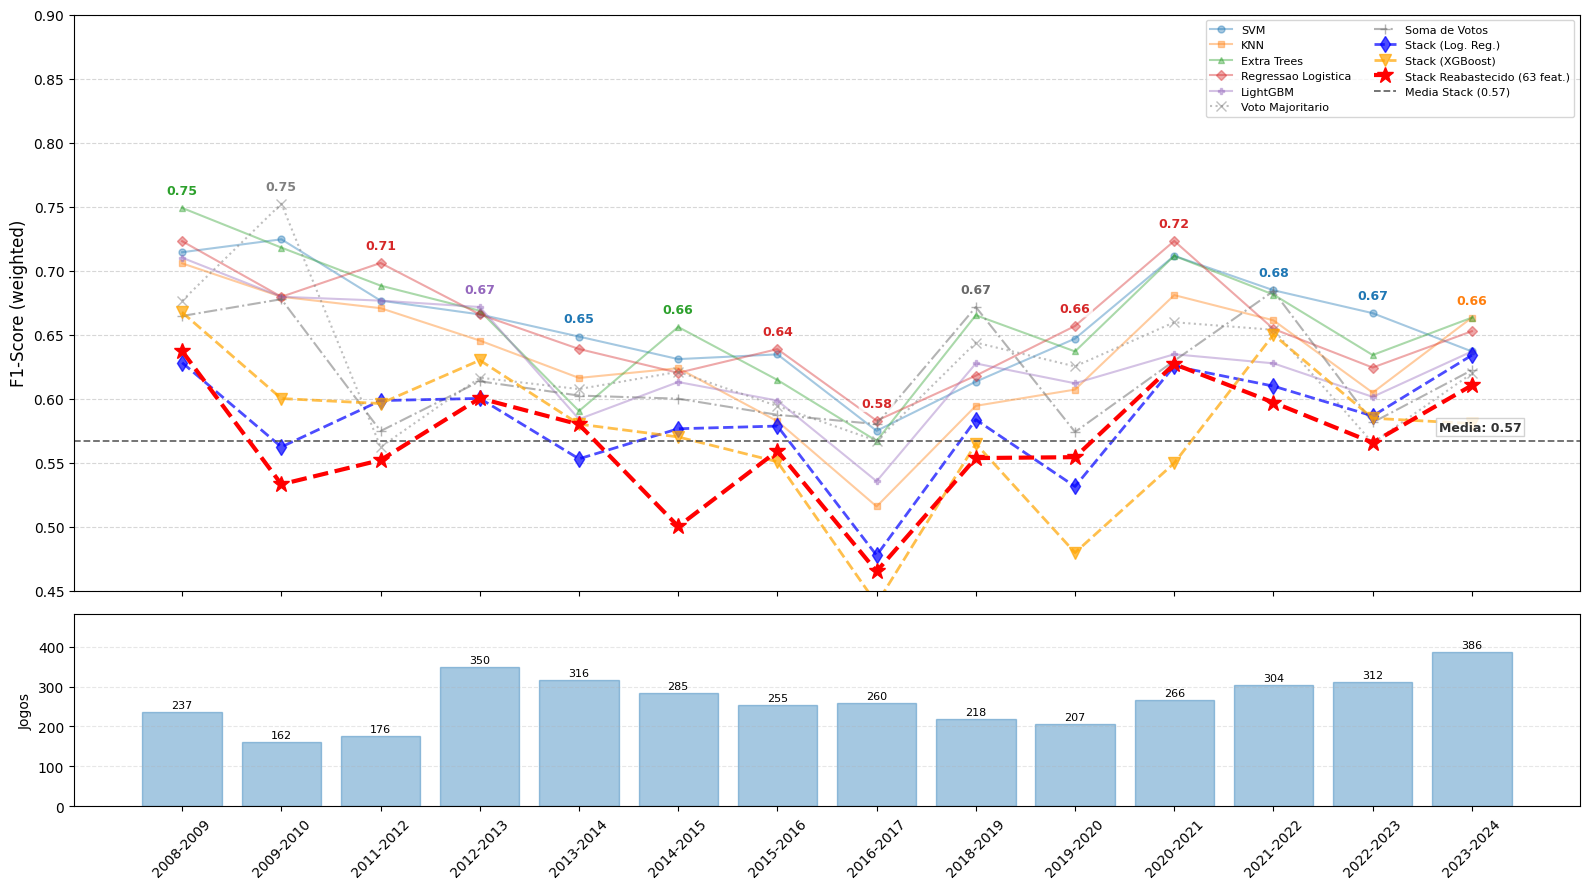


Janela = 5 - Resumo Stack Reabastecido:
Temporada  Jogos Avaliados  Acurácia  F1-Score
2008-2009              226    0.6726    0.6370
2009-2010              151    0.6623    0.5330
2011-2012              165    0.6545    0.5519
2012-2013              339    0.6549    0.6002
2013-2014              305    0.6230    0.5798
2014-2015              274    0.6095    0.5001
2015-2016              244    0.5738    0.5591
2016-2017              249    0.5261    0.4650
2018-2019              207    0.6087    0.5535
2019-2020              196    0.5561    0.5542
2020-2021              255    0.6588    0.6269
2021-2022              293    0.6451    0.5969
2022-2023              301    0.5847    0.5656
2023-2024              375    0.6400    0.6103



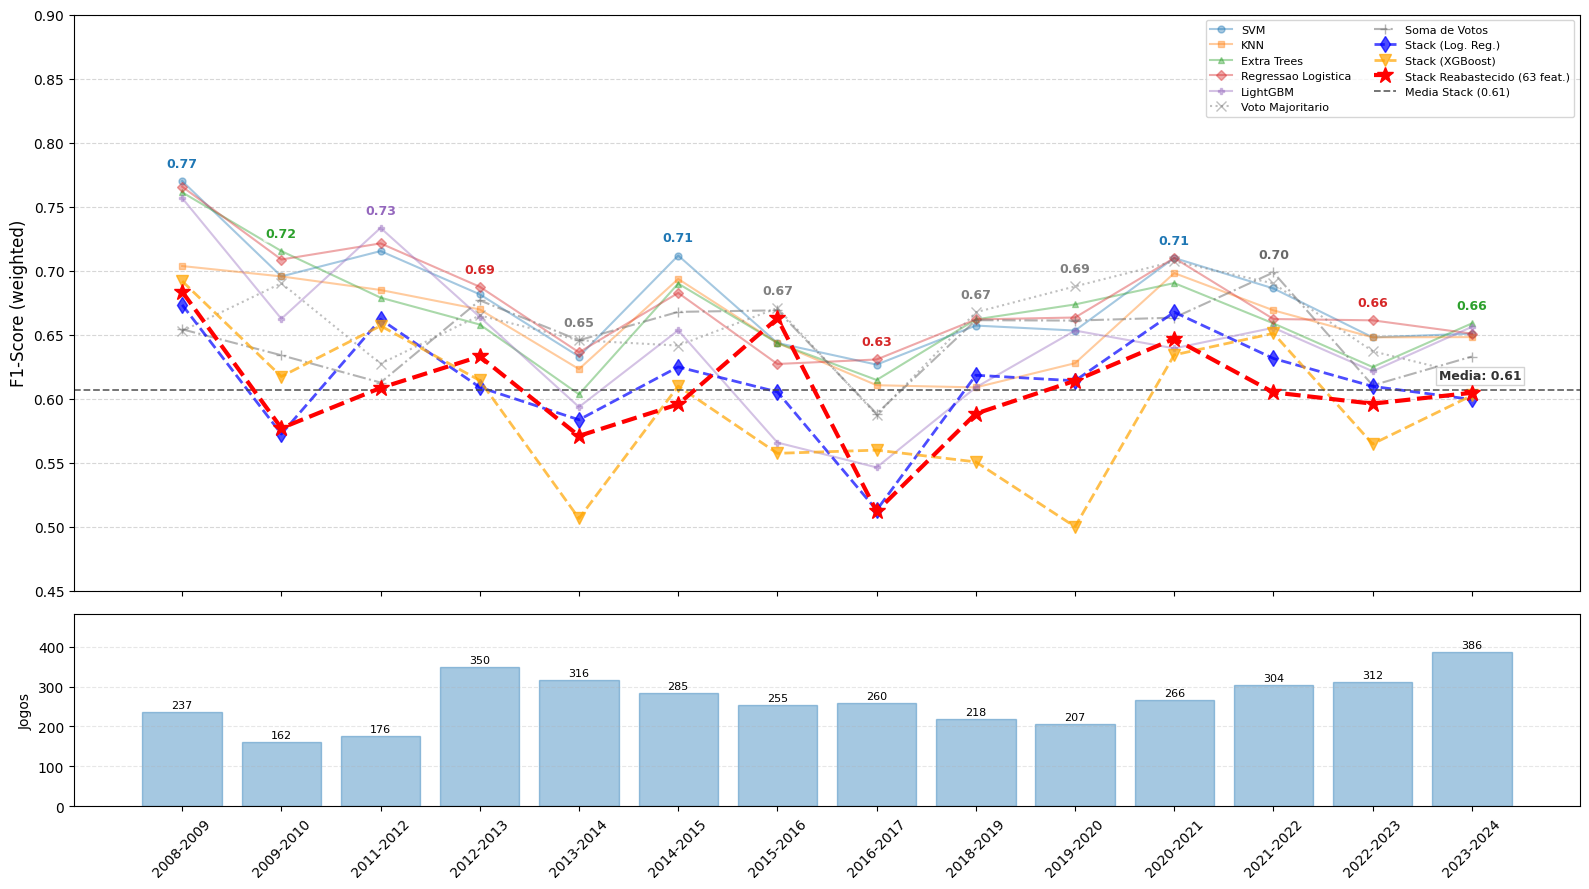


Janela = 10 - Resumo Stack Reabastecido:
Temporada  Jogos Avaliados  Acurácia  F1-Score
2008-2009              216    0.7176    0.6835
2009-2010              141    0.6738    0.5769
2011-2012              155    0.6968    0.6083
2012-2013              329    0.6687    0.6329
2013-2014              295    0.6169    0.5708
2014-2015              264    0.6439    0.5955
2015-2016              234    0.6752    0.6626
2016-2017              239    0.5523    0.5119
2018-2019              197    0.6091    0.5882
2019-2020              186    0.6183    0.6139
2020-2021              245    0.6694    0.6467
2021-2022              283    0.6572    0.6048
2022-2023              291    0.6082    0.5960
2023-2024              365    0.6356    0.6045



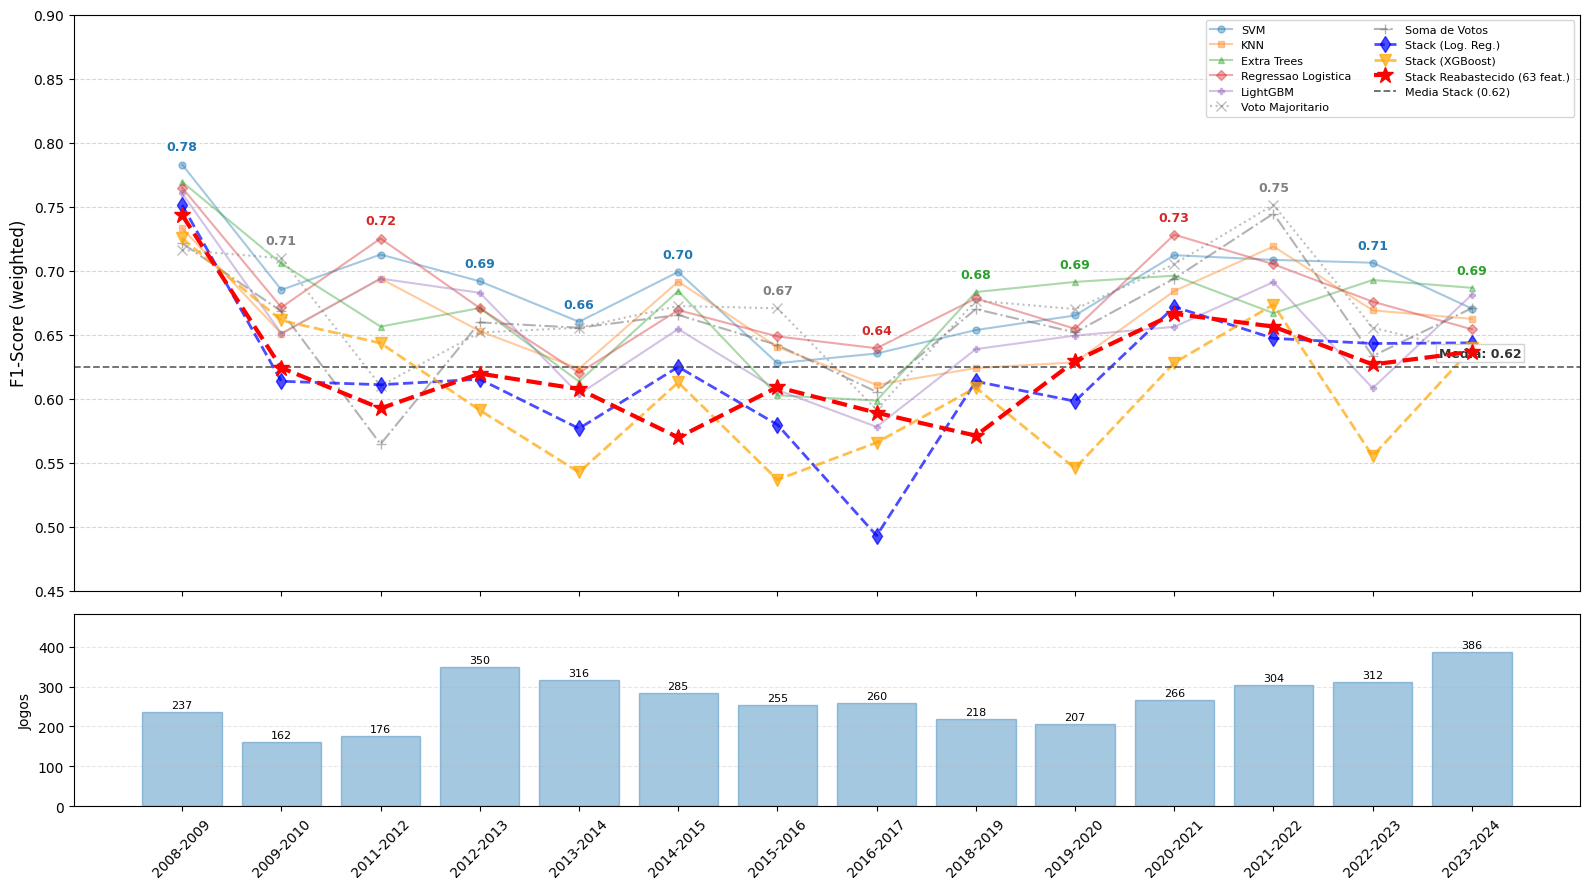


Janela = 15 - Resumo Stack Reabastecido:
Temporada  Jogos Avaliados  Acurácia  F1-Score
2008-2009              206    0.7670    0.7433
2009-2010              131    0.6947    0.6240
2011-2012              145    0.6828    0.5923
2012-2013              319    0.6552    0.6195
2013-2014              285    0.6421    0.6074
2014-2015              254    0.6260    0.5696
2015-2016              224    0.6429    0.6089
2016-2017              229    0.6026    0.5889
2018-2019              187    0.6257    0.5710
2019-2020              176    0.6307    0.6293
2020-2021              235    0.6851    0.6662
2021-2022              273    0.6850    0.6562
2022-2023              281    0.6370    0.6266
2023-2024              355    0.6592    0.6366



In [10]:
for janela in JANELAS:
    plot_comparativo(janela)

## Distribuição das Previsões vs Realidade

Para entender melhor onde o modelo está acertando ou errando, comparei a distribuição das **previsões** com a distribuição dos **resultados reais**. Se o modelo prever classe 1 muito mais (ou menos) do que a realidade, pode indicar um viés.

In [11]:
print('DISTRIBUICAO DAS PREVISOES vs REALIDADE (Stack Reabastecido)')
print('=' * 80)

for janela in JANELAS:
    df_j = df_predicoes[df_predicoes['Janela Incremental'] == janela]
    total = len(df_j)

    prev_1 = int((df_j['Previsao'] == 1).sum())
    prev_0 = int((df_j['Previsao'] == 0).sum())

    real_1 = int((df_j['Resultado Real'] == 1).sum())
    real_0 = int((df_j['Resultado Real'] == 0).sum())

    print(f'\nJanela={janela:>2}')
    print(f'  Previsoes:  total={total} | classe_1={prev_1} | classe_0={prev_0} | {prev_1}/{total} = {prev_1/total:.4f}')
    print(f'  Realidade:  total={total} | classe_1={real_1} | classe_0={real_0} | {real_1}/{total} = {real_1/total:.4f}')
    print(f'  Diferenca:  o modelo preve {abs(prev_1 - real_1)} jogos {"a mais" if prev_1 > real_1 else "a menos"} como classe 1')

DISTRIBUICAO DAS PREVISOES vs REALIDADE (Stack Reabastecido)

Janela= 5
  Previsoes:  total=3580 | classe_1=2894 | classe_0=686 | 2894/3580 = 0.8084
  Realidade:  total=3580 | classe_1=2110 | classe_0=1470 | 2110/3580 = 0.5894
  Diferenca:  o modelo preve 784 jogos a mais como classe 1

Janela=10
  Previsoes:  total=3440 | classe_1=2687 | classe_0=753 | 2687/3440 = 0.7811
  Realidade:  total=3440 | classe_1=2039 | classe_0=1401 | 2039/3440 = 0.5927
  Diferenca:  o modelo preve 648 jogos a mais como classe 1

Janela=15
  Previsoes:  total=3300 | classe_1=2555 | classe_0=745 | 2555/3300 = 0.7742
  Realidade:  total=3300 | classe_1=1955 | classe_0=1345 | 1955/3300 = 0.5924
  Diferenca:  o modelo preve 600 jogos a mais como classe 1


## Só por curiosidade

Antes de olhar para o stack final, vamos olhar para o que ele recebe dos modelos base.

O stack reabastecido usa as probabilidades geradas por SVM, KNN, Extra Trees, Regressao Logistica e LightGBM. Entao, se esses modelos entregam muitas probabilidades perto de `0.50`, eles nao estao ajudando tanto o stack a decidir. Eles estao dizendo algo como: "pode ser classe 0, pode ser classe 1".

Nesta celula, olhamos tres coisas:

- a probabilidade media da Classe 1 em cada modelo;
- quantas previsoes ficam muito perto da duvida, entre `0.45` e `0.55`;
- quantas previsoes ficam numa zona ainda meio morna, entre `0.40` e `0.60`;
- quantas previsoes sao mais confiantes, abaixo de `0.35` ou acima de `0.65`.

O ponto principal aqui e verificar se os modelos base chegam no stack com sinais fortes ou com sinais indecisos

In [12]:
print('ANALISE DE INDECISAO DOS MODELOS BASE')
print('=' * 80)

df_indecisao = df_enriched.copy()

resumo_indecisao = []

for modelo in PROB_FEATURES:
    prob = df_indecisao[modelo]

    resumo_indecisao.append({
        'Modelo': modelo,
        'Prob Media Classe 1': prob.mean(),
        '% Entre 0.45 e 0.55': ((prob >= 0.45) & (prob <= 0.55)).mean(),
        '% Entre 0.40 e 0.60': ((prob >= 0.40) & (prob <= 0.60)).mean(),
        '% Confiantes': ((prob <= 0.35) | (prob >= 0.65)).mean(),
    })

df_resumo_indecisao = pd.DataFrame(resumo_indecisao)

display(
    df_resumo_indecisao
    .sort_values('% Entre 0.40 e 0.60', ascending=False)
    .style.format({
        'Prob Media Classe 1': '{:.4f}',
        '% Entre 0.45 e 0.55': '{:.2%}',
        '% Entre 0.40 e 0.60': '{:.2%}',
        '% Confiantes': '{:.2%}',
    })
)

ANALISE DE INDECISAO DOS MODELOS BASE


,Modelo,Prob Media Classe 1,% Entre 0.45 e 0.55,% Entre 0.40 e 0.60,% Confiantes
0,prob_svm,0.5829,20.93%,40.90%,42.58%
2,prob_extra_trees,0.5830,19.12%,36.93%,48.04%
3,prob_regressao_logistica,0.5938,17.06%,31.60%,53.00%
1,prob_knn,0.5891,5.96%,29.36%,65.03%
4,prob_lightgbm,0.5938,12.03%,21.93%,69.44%
